Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Figuras

In [ ]:
def plot_history(history):
    history_tl_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history_tl_df['loss'], label='Training Loss')
    axes[0].plot(history_tl_df['val_loss'], label='Validation Loss')
    axes[0].set_title('Cross-entropy Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history_tl_df['binary_accuracy'], label='Training Accuracy')
    axes[1].plot(history_tl_df['val_binary_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Binary Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def prediction_results(model, train_ds, val_ds):
    class_names = train_ds.class_names
    rows, cols = 4, 5

    # Take one batch from validation set
    for images, labels in val_ds.take(1):
        predictions = model.predict(images)
        predictions = tf.squeeze(predictions)

        # Set up horizontal layout
        num_images = min(rows * cols, len(images))
        plt.figure(figsize=(cols * 3, rows * 3))  # Adjust width as needed

        for i in range(num_images):
            plt.subplot(rows, cols, i + 1)  # 1 row, N columns
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.axis("off")

            pred_label = class_names[int(predictions[i] > 0.5)]
            true_label = class_names[int(labels[i])]
            confidence = float(predictions[i])

            color = "green" if pred_label == true_label else "red"
            plt.title(f"{pred_label} ({confidence:.2f})\nTrue: {true_label}", color=color)

        plt.tight_layout()
        plt.show()

Preprocesamiento

In [ ]:
zip_file_path = '/content/drive/MyDrive/clubes_2025/python/imgs.zip'
extract_to_path = '/content'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

In [ ]:
folder = 'imgs'
#folder = 'Fotos'

# Preprocesamiento
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"/content/{folder}",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"/content/{folder}",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

Found 102 files belonging to 2 classes.
Using 82 files for training.
Found 102 files belonging to 2 classes.
Using 20 files for validation.


Multilayer Perceptron (MLP)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - binary_accuracy: 0.6427 - loss: 0.5878 - val_binary_accuracy: 0.8000 - val_loss: 448.2495
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - binary_accuracy: 0.9561 - loss: 0.1471 - val_binary_accuracy: 0.8000 - val_loss: 174.1777
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 8s/step - binary_accuracy: 0.9839 - loss: 0.1036 - val_binary_accuracy: 0.8000 - val_loss: 114.9754
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - binary_accuracy: 0.9344 - loss: 0.1351 - val_binary_accuracy: 0.8000 - val_loss: 86.5463
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - binary_accuracy: 0.9739 - loss: 0.0734 - val_binary_accuracy: 0.8000 - val_loss: 74.5657


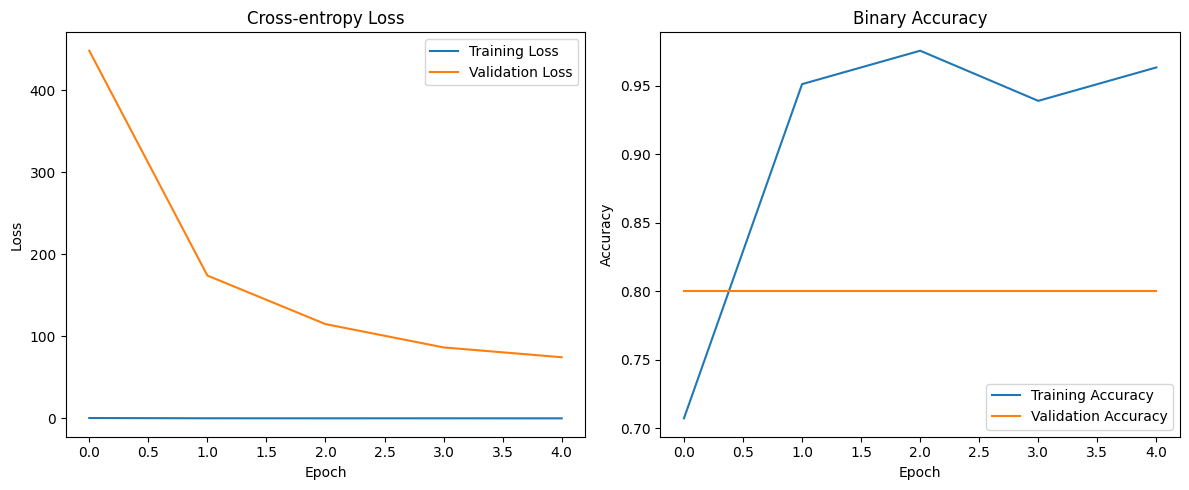

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


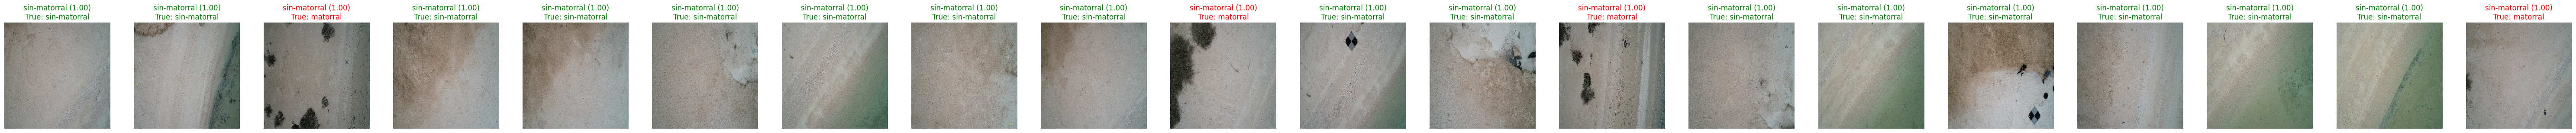

In [ ]:
# Clasificador MLP
model_mlp = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Flatten(),  # Flatten the image

    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),

    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

# Compilador
model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

history_MLP = model_mlp.fit(train_ds, validation_data=val_ds, epochs=5)

#Visualización de resultados
plot_history(history_MLP)
prediction_results(model_mlp, train_ds, val_ds)

#Guarda tu modelo
name = 'MLP_model'
model_mlp.save(f"{name}.keras")

Convolusional Neural Network (CNN)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - binary_accuracy: 0.5769 - loss: 8.3584 - val_binary_accuracy: 0.5500 - val_loss: 0.6524
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - binary_accuracy: 0.6804 - loss: 0.8681 - val_binary_accuracy: 0.8000 - val_loss: 0.3943
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - binary_accuracy: 0.7187 - loss: 0.4753 - val_binary_accuracy: 0.9000 - val_loss: 0.3582
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - binary_accuracy: 0.8965 - loss: 0.3125 - val_binary_accuracy: 0.8000 - val_loss: 0.3571
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - binary_accuracy: 0.8926 - loss: 0.3139 - val_binary_accuracy: 0.9500 - val_loss: 0.2730


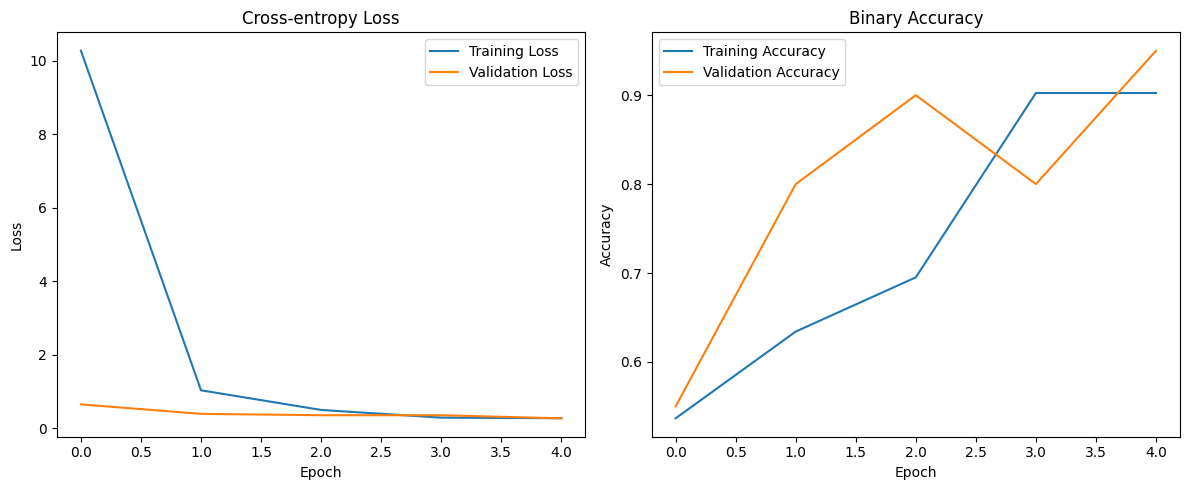

In [ ]:
# Clasificador CNN
model_cnn = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Binary output
    layers.Dense(1, activation='sigmoid')
])

# Compilador
model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=5)

#Visualización de resultados
plot_history(history_cnn)
prediction_results(model_cnn, train_ds, val_ds)

#Guarda tu modelo
name = 'CNN_model'
model_cnn.save(f"{name}.keras")

Transfer Learning

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - binary_accuracy: 0.5117 - loss: 1.2252 - val_binary_accuracy: 0.2000 - val_loss: 1.4151
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - binary_accuracy: 0.3961 - loss: 0.9009 - val_binary_accuracy: 0.3000 - val_loss: 0.8034
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - binary_accuracy: 0.4170 - loss: 0.7996 - val_binary_accuracy: 0.7000 - val_loss: 0.6006
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - binary_accuracy: 0.4805 - loss: 0.8021 - val_binary_accuracy: 0.7500 - val_loss: 0.5506
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - binary_accuracy: 0.5278 - loss: 0.6729 - val_binary_accuracy: 0.7500 - val_loss: 0.5640


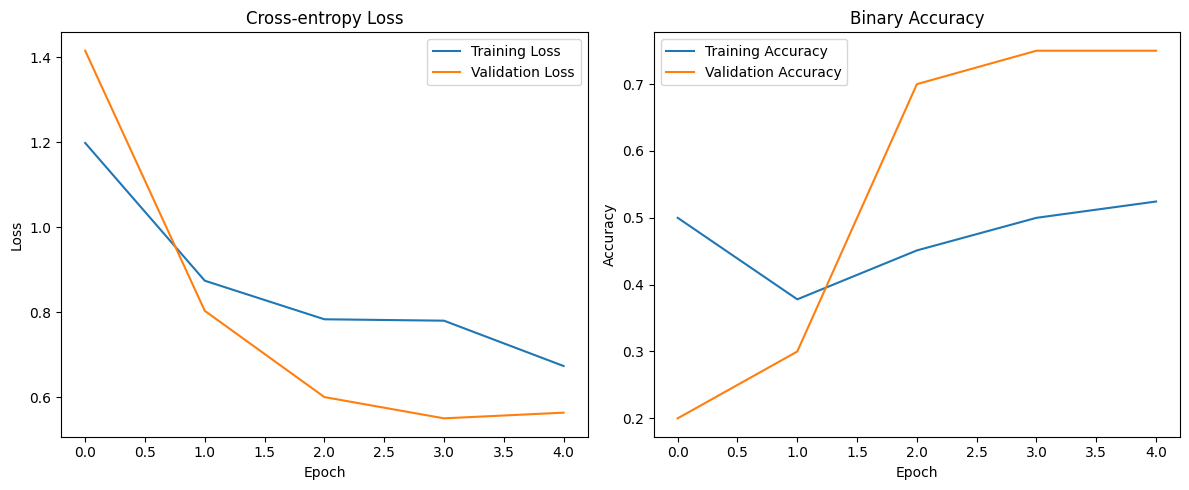

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


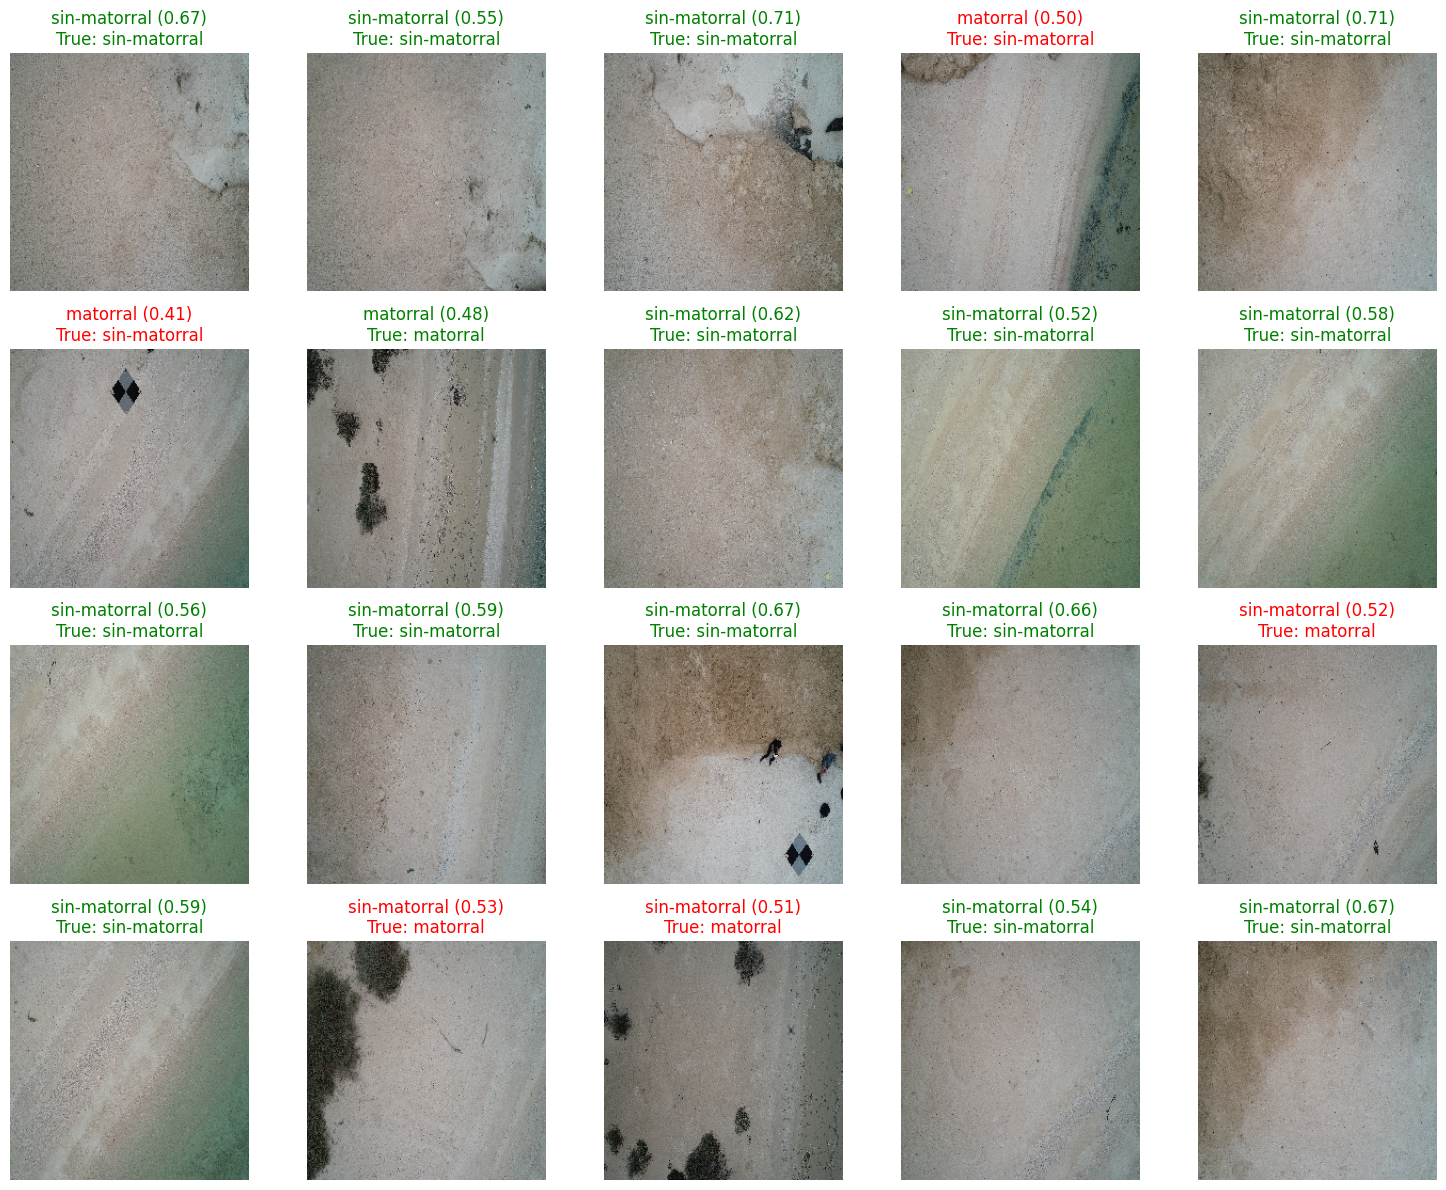

In [ ]:
# Modelo base
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

# Clasificador
model_tl = Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

# Compilador
model_tl.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['binary_accuracy'])

# Entrenamiento
history_tl = model_tl.fit(train_ds, validation_data=val_ds, epochs=5)

#Visualización de resultados
plot_history(history_tl)
prediction_results(model_tl, train_ds, val_ds)

#Guarda tu modelo
name = 'TL_model'
model_tl.save(f"{name}.keras")